In [ ]:
# load cleaned data
import pickle 
with open("transcripts_speech_clean.pickle", "rb") as f:
    transcripts = pickle.load(f)

In [ ]:
import polars as pl
import numpy as np
import spacy
from collections import Counter
nlp = spacy.load('en_core_web_sm')


['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

In [ ]:
# Some minor changes: as we have discussed previously 
# the null-values in this columns are nothing but trouble when we try to filter
transcripts = transcripts.with_columns(
    pl.when(pl.col("event").is_null())
    .then(pl.lit("Discussion"))
    .otherwise("event")
    .alias("event")
)

# for now, we only want to look at the discussion
corpus = transcripts.filter(
    pl.col("event").is_in(["Reading Story", "Reading Poem"]).not_()
)

In [ ]:
# All of the discussion is now one string
corpus = corpus.select(pl.col("speech").str.join(" "))
corpus

polars.dataframe.frame.DataFrame

In [ ]:
# process with spacy
doc = nlp(corpus["speech"][0])

In [282]:
# First we lemmatize
tokens = []
lemmas = []
for token in doc:
    if not token.is_stop and not token.is_punct:
        print(token.text, token.lemma_)
        tokens.append(token.text)
        lemmas.append(token.lemma_)

   
UM um
going go
time time
shared share
reading reading
Yes yes
Yeah yeah
OK ok
generally generally
read read
Yeah yeah
couple couple
sessions session
UM um
got get
today today
story story
poem poem
UM um
bit bit
longer long
short short
story story
probably probably
spend spend
time time
sort sort
finish finish
poem poem
UM um
copy copy
UM um
read read
little little
bit bit
loud loud
stop stop
different different
points point
kind kind
chat chat
going go
story story
UM um
UH uh
UM um
bit bit
reading read
aloud aloud
feel feel
like like
pressure pressure
UM um
   
story story
called call
Accelerate Accelerate
Frank Frank
Cottrell Cottrell
Boyce Boyce
   
stop stop
bit bit
UM um
   
UM um
   
picture picture
Wendy Wendy
like like
Wendy Wendy
focused focused
30 30
seconds second
Yeah yeah
yeah yeah
watched watch
TV tv
like like
game game
like like
oh oh
30 30
seconds second
short short
funny funny
know know
described describe
big big
clock clock
UM um
UM um
sort sort
focus focus
passing

In [ ]:
# read in the VAD norms
vad_norms = pl.read_csv("maxqda_export/BRM-emot-submit.csv", ignore_errors=True)
vad_norms.describe()

statistic,,Word,V.Mean.Sum,V.SD.Sum,V.Rat.Sum,A.Mean.Sum,A.SD.Sum,A.Rat.Sum,D.Mean.Sum,D.SD.Sum,D.Rat.Sum,V.Mean.M,V.SD.M,V.Rat.M,V.Mean.F,V.SD.F,V.Rat.F,A.Mean.M,A.SD.M,A.Rat.M,A.Mean.F,A.SD.F,A.Rat.F,D.Mean.M,D.SD.M,D.Rat.M,D.Mean.F,D.SD.F,D.Rat.F,V.Mean.Y,V.SD.Y,V.Rat.Y,V.Mean.O,V.SD.O,V.Rat.O,A.Mean.Y,A.SD.Y,A.Rat.Y,A.Mean.O,A.SD.O,A.Rat.O,D.Mean.Y,D.SD.Y,D.Rat.Y,D.Mean.O,D.SD.O,D.Rat.O,V.Mean.L,V.SD.L,V.Rat.L,V.Mean.H,V.SD.H,V.Rat.H,A.Mean.L,A.SD.L,A.Rat.L,A.Mean.H,A.SD.H,A.Rat.H,D.Mean.L,D.SD.L,D.Rat.L,D.Mean.H,D.SD.H,D.Rat.H
str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",13915.0,"""13915""",13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13914.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0,13915.0
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",6958.0,null,5.063847,1.679261,21.812433,4.210582,2.300198,22.974057,5.184773,2.159786,24.315128,5.133611,1.600304,8.394969,5.006289,1.640649,13.267697,4.38344,2.272488,8.597916,4.097754,2.284505,14.202012,5.172114,2.153488,10.700611,5.188133,2.125138,13.502695,5.098263,1.67503,10.453611,5.04447,1.607655,11.184908,4.309259,2.305631,10.417822,4.127317,2.26642,12.456486,5.124307,2.172035,13.309881,5.20482,2.042994,10.905282,5.037698,1.697664,12.019475,5.096405,1.575082,9.792957,4.145347,2.332415,12.733956,4.284328,2.171885,10.240101,5.196908,2.218375,13.237657,5.170126,2.024414,11.07747
"""std""",4017.058833,null,1.274892,0.350281,23.441875,0.896413,0.320252,24.726507,0.938284,0.328592,25.0668,1.288822,0.572068,9.5051,1.386461,0.441505,14.457712,1.091553,0.501159,9.496621,0.989901,0.410796,15.424195,1.006799,0.48306,11.284547,1.093638,0.450448,14.154644,1.297328,0.506751,11.581916,1.397681,0.477181,12.184495,1.038282,0.477671,11.441644,1.046031,0.434067,13.538515,0.961689,0.45073,14.134225,1.196106,0.516067,11.419469,1.304012,0.449887,13.060726,1.368786,0.491413,10.645254,1.030653,0.444142,13.958102,1.093094,0.51423,11.379156,1.051368,0.465165,13.913171,1.074364,0.504523,11.675659
"""min""",1.0,"""AIDS""",1.26,0.31,16.0,1.6,0.88,16.0,1.68,0.78,14.0,1.0,0.0,2.0,1.17,0.0,5.0,1.17,0.41,3.0,1.3,0.53,7.0,1.17,0.38,4.0,1.5,0.3,6.0,1.0,0.0,2.0,1.0,0.0,4.0,1.0,0.0,4.0,1.5,0.53,5.0,1.43,0.44,4.0,1.2,0.0,4.0,1.08,0.0,6.0,1.0,0.0,5.0,1.25,0.48,5.0,1.12,0.0,1.0,1.67,0.52,5.0,1.33,0.0,2.0
"""25%""",3480.0,null,4.25,1.43,19.0,3.56,2.08,20.0,4.58,1.94,20.0,4.33,1.21,6.0,4.09,1.34,10.0,3.62,1.95,6.0,3.38,2.0,12.0,4.5,1.84,8.0,4.5,1.81,10.0,4.27,1.34,8.0,4.17,1.28,9.0,3.6,1.98,9.0,3.36,1.96,11.0,4.5,1.88,10.0,4.43,1.69,8.0,4.2,1.38,10.0,4.2,1.24,8.0,3.41,2.04,10.0,3.5,1.85,8.0,4.5,1.9,9.0,4.5,1.67,9.0
"""50%""",6958.0,null,5.2,1.67,20.0,4.11,2.3,21.0,5.26,2.17,22.0,5.25,1.58,8.0,5.1,1.63,13.0,4.33,2.3,8.0,4.0,2.29,13.0,5.21,2.17,10.0,5.27,2.13,12.0,5.18,1.66,10.0,5.17,1.58,10.0,4.29,2.32,10.0,4.0,2.27,12.0,5.18,2.19,12.0,5.31,2.05,10.0,5.14,1.68,12.0,5.22,1.55,9.0,4.06,2.34,11.0,4.2,2.19,10.0,5.25,2.22,12.0,5.25,2.03,10.0
"""75%""",10437.0,null,5.95,1.91,21.0,4.76,2.52,23.0,5.84,2.38,25.0,6.0,1.97,10.0,5.96,1.93,15.0,5.09,2.62,10.0,4.73,2.57,15.0,5.89,2.49,12.0,5.93,2.44,15.0,6.0,2.01,11.0,6.0,1.92,12.0,5.0,2.65,11.0,4.79,2.57,13.0,5.8,2.48,15.0,6.

In [39]:
vad_norms = vad_norms.select(
    "Word", 
    valence = pl.col("V.Mean.Sum"),
    arousal = pl.col("A.Mean.Sum"),
    dominance = pl.col("D.Mean.Sum")
)
vad_norms.head()

Word,valence,arousal,dominance
str,f64,f64,f64
"""aardvark""",6.26,2.41,4.27
"""abalone""",5.3,2.65,4.95
"""abandon""",2.84,3.73,3.32
"""abandonment""",2.63,4.95,2.64
"""abbey""",5.85,2.2,5.0


In [ ]:
# build a df with our lemmas and their frequency
vad_transcripts = pl.DataFrame(
    {
        "Word": lemmas
    }
).group_by("Word").agg(pl.len().alias("frequency"))

In [ ]:
# add the vad norms
vad_transcripts = vad_transcripts.join(
    vad_norms, on="Word", how="inner"
)

In [ ]:
# do decile split
deciles = vad_transcripts.with_columns(
    (
        (pl.col("valence").rank(method='min') / vad_transcripts.height * 10)
        .ceil()
        .cast(pl.UInt32)
        .alias("v.decile")
    )
)

In [68]:
top = deciles.filter(pl.col("v.decile")==10)
bottom = deciles.filter(pl.col("v.decile")==1)

top_dic = top.select("Word", "frequency").rows_by_key(key="Word", unique=True)
top_dic = {k: v[0] for k, v in top_dic.items()}

bottom_dic = bottom.select("Word", "frequency").rows_by_key(key="Word", unique=True)
bottom_dic = {k: v[0] for k, v in bottom_dic.items()}

top_dic

{'accomplish': 1,
 'accomplishment': 3,
 'accurate': 1,
 'adventure': 1,
 'agree': 27,
 'amazing': 14,
 'ancient': 1,
 'appreciate': 6,
 'awesome': 2,
 'bargain': 1,
 'beach': 37,
 'beautiful': 37,
 'beauty': 3,
 'bed': 2,
 'blooming': 1,
 'brilliant': 3,
 'bunny': 1,
 'care': 40,
 'celebrate': 2,
 'child': 119,
 'clarity': 1,
 'clever': 2,
 'comfort': 8,
 'comforting': 4,
 'comic': 1,
 'confident': 2,
 'considerate': 1,
 'courage': 2,
 'courageous': 1,
 'create': 9,
 'cure': 1,
 'cute': 8,
 'dance': 8,
 'date': 2,
 'daytime': 2,
 'delight': 2,
 'discover': 1,
 'dream': 42,
 'easy': 11,
 'empathy': 5,
 'encourage': 3,
 'endearing': 1,
 'enjoy': 27,
 'enjoyable': 3,
 'enjoyment': 2,
 'entertainment': 1,
 'enthusiastic': 1,
 'excite': 2,
 'excited': 22,
 'excitement': 3,
 'exciting': 11,
 'exhilarating': 1,
 'fairness': 1,
 'faithful': 1,
 'family': 19,
 'fancy': 11,
 'fantastic': 2,
 'fantasy': 4,
 'fascinating': 1,
 'favorite': 2,
 'feast': 3,
 'female': 1,
 'first': 85,
 'flower': 4,


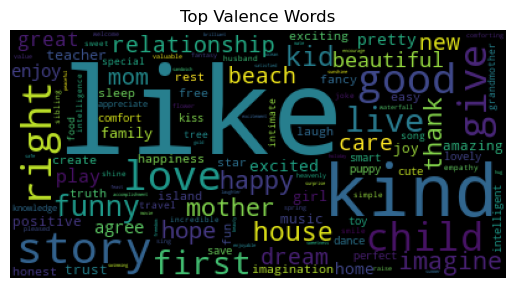

In [70]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt

top_wc = WordCloud().generate_from_frequencies(top_dic)

plt.figure()
plt.title("Top Valence Words")
plt.imshow(top_wc)
plt.axis("off")
plt.show()


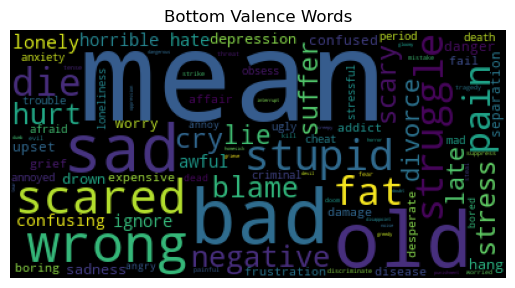

In [71]:
bottom_wc = WordCloud().generate_from_frequencies(bottom_dic)

plt.figure()
plt.title("Bottom Valence Words")
plt.imshow(bottom_wc)
plt.axis("off")
plt.show()

In [ ]:
# This is a whole lot of Data wrangling. To compare the discussion sections with the respective readings, 
# we need a way to uniquely identify and link them #

trans_sections = transcripts.with_columns(
    # identify when a reading has ended
    pl.when(((pl.col("event") != "Reading Story") & 
            (pl.col("event").shift(1) == "Reading Story"))
    ).then(
        pl.lit("discussion story")
    ).when(((pl.col("event") != "Reading Poem") & 
            (pl.col("event").shift(1) == "Reading Poem"))
    ).then(
        pl.lit("discussion poem")
    # identify when reading starts
    ).when((pl.col("event").is_in(["Reading Story", "Reading Poem"])) &
           (pl.col("event").shift(1).is_in(["Reading Story", "Reading Poem"]).not_())
    ).then(pl.col("event"))
    .alias("topic")
).filter(
    # we don't need the reading of the text, we will replace this later with the actual text
    (pl.col("event").is_in(["Reading Story", "Reading Poem"]) & pl.col("topic").is_null()).not_()
).with_columns(
    # count the number of discussions so we can identify them
    (pl.col("topic") == "discussion story").cum_sum().fill_null(strategy="forward").over(pl.col("session")).alias("index_sd"),  
    (pl.col("topic") == "discussion poem").cum_sum().fill_null(strategy="forward").over(pl.col("session")).alias("index_pd"),
    pl.col("topic").forward_fill().over(pl.col("session"))  
).with_columns(
    # match the readings (they're always 1 behind since we started counting with the first discussion)
    pl.when(pl.col("topic") == "Reading Story")
    .then(
        pl.col("index_sd") + 1
        )
    .otherwise(pl.col("index_sd")),
    pl.when(pl.col("topic") == "Reading Poem")
    .then(
        pl.col("index_pd") + 1
        )
    .otherwise(pl.col("index_pd"))
).with_columns(
    # create a unique identifier
    pl.when(pl.col("topic").is_in(["discussion story", "Reading Story"]))
    .then(pl.col("topic") + pl.lit("_") + pl.col("index_sd").cast(pl.String))
    .when(pl.col("topic").is_in(["discussion poem", "Reading Poem"]))
    .then(pl.col("topic") + pl.lit("_") + pl.col("index_pd").cast(pl.String))
    .otherwise(pl.lit("intro")).alias("index")
).select("session", "speaker", "speech", "time", "event", "index")

In [ ]:
# Read in the original texts 
reading = pl.read_excel("maxqda_export/Lit_Texts/Liverpool_texts.xlsx").with_columns(
    # add the matching unique identifyer for the text-snippets
    pl.when(pl.col("text_type") == "story")
    .then((pl.lit("Reading Story_") + pl.col("snippet_id").cast(pl.String)).alias("index"))
    .when((pl.col("text_type") == "poem"))
    .then((pl.lit("Reading Poem_") + pl.col("snippet_id").cast(pl.String)).alias("index")),
    pl.col("session").cast(pl.String).alias("session")
).with_columns(
    # match session names
    pl.when(pl.col("session") != "10")
    .then(pl.lit("0") + pl.col("session"))
    .otherwise(pl.lit("10")).alias("session")
).select("session", "title", "index",
         speech = "snippet")

In [ ]:
# merge the transcripts with the readings 
full_data = trans_sections.join(reading, on=["session", "index"], how="left").with_columns(
    # replace og texts in speech with readings
    pl.when(pl.col("event").is_in(["Reading Story", "Reading Poem"]))
    .then(pl.col("speech_right").alias("speech"))
    .otherwise(pl.col("speech"))
).with_columns(
    pl.col("title").fill_null(strategy="forward").over("session")
).drop("speech_right")

In [ ]:
# this is a function that runs spacy processing on the text and extracting the lemmas
def process(text):
    parsed_text = nlp(text)
    full_vocab = [token.lemma_.lower() for token in parsed_text \
                  if not token.is_stop and \
                    not token.is_punct]

    return full_vocab

# function to return the mean sentiment of a list of lemmas
def get_vad(lemmas, norm):
    norms = []
    
    for i in lemmas:
        if i in vad_norms["Word"]: 
            n = vad_norms.filter(pl.col("Word") == i).item(0, norm)
            norms.append(n)

    if norms.__len__() > 1:
        return np.mean(norms)
    if norms.__len__() == 1:
        return norms[0]
    else: 
        return None


In [ ]:
# now we apply this
session_vad = full_data.group_by("session", "title", "index", maintain_order=True).agg(
    speech = pl.col("speech").str.join(" ")
).with_columns(
    pl.col("speech").map_elements(lambda t: process(t), return_dtype=pl.List(pl.Utf8)).alias("lemmas")
).with_columns(
    pl.col("lemmas").map_elements(lambda l: get_vad(l, "valence"), return_dtype=pl.Float64).alias("valence"),
    pl.col("lemmas").map_elements(lambda l: get_vad(l, "arousal"), return_dtype=pl.Float64).alias("arousal"),
    pl.col("lemmas").map_elements(lambda l: get_vad(l, "dominance"), return_dtype=pl.Float64).alias("dominance")
)

In [225]:
import altair as alt


In [ ]:
# let's check out how this behaves
plot_data = session_vad.filter(
    (pl.col("session") == "05") & (pl.col("title") == "The Way It Is")
).with_columns(
    pl.col("index").alias("event")
).drop("index").unpivot(
    on=["valence", "arousal", "dominance"],
    index="event",
    variable_name="vad",
    value_name="value"
).with_row_index()


In [258]:
alt.Chart(plot_data).mark_line().encode(
    alt.X('event', sort=plot_data["index"]),
    alt.Y("value:Q").scale(zero=False),
    color='vad'
).properties(
    width=800
)

alt.Chart(...)

In [260]:
likes = []

sentences = list(doc.sents)

for sentence in sentences:
    is_like = False
    for token in sentence:
        if token.lemma_ == "like":
            is_like = True

    if is_like == True:
        likes.append(sentence)

likes

[And [UH] you can, you can [UM] do a bit of reading aloud yourself if you feel like it.,
 At first, I was like, why is Wendy so focused on these 30 seconds?,
 I've never watched TV about like a game show.,
 And been like, oh, only 30 seconds.,
 [UM] and [UM] sort of being made to focus on the passing of the time like that.,
 [UM] Well there's like the music as well that goes with it isn't there,
 I quite liked the contrast between  the way she was struggling with what like.,
 In contrast to the baby who was like just able to lie there for half an hour just looking at his own fingers.,
 And I think that's quite an interesting difference between, I don't know, maybe it's showing like the difference between her and the child.,
 but it's quite, I like, I liked that because I think.  ,
 Maybe just in life you go through different stages of like how much you can cope with Mmm!,
 Yeah, I love all like the disconjoining thoughts about like when the baby's napping.,
 It's very much like, you kn

In [267]:
pos_likes = []

for sentence in likes:
    for token in sentence:
        if token.lemma_ == "like":
            pos_likes.append(token.pos_)

pos_likes = set(pos_likes)
pos_likes

{'ADJ', 'ADP', 'AUX', 'INTJ', 'SCONJ', 'VERB'}

In [271]:
test = 3
test -=1 
print(test)

2


In [278]:
from spacy import displacy
for case in pos_likes:
    examples = 2
    print(case)   
    for sentence in likes:
        for token in sentence:
            if (token.lemma_ == "like") & (token.pos_ == case):
                displacy.render(sentence, style="dep", jupyter=True)
                examples -= 1
        if examples < 1: break
                    



ADP


SCONJ


ADJ


VERB


AUX


INTJ
